# ASSOCIATION RULE MINING (Apriori Analysis)

In [8]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

In [9]:
disease_df = pd.read_csv("../data/processed/processed_disease_matrix.csv")
disease_df.head()

,HighBP,HighChol,Stroke,HeartDiseaseorAttack,DiffWalk,Obesity,PoorGenHlth,Diabetes_binary
0,1,1,0,0,1,1,1,0
1,0,0,0,0,0,0,0,0
2,1,1,0,0,1,0,1,0
3,1,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0


In [10]:
frequent_itemsets = apriori(disease_df, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets.head(10)

C:\Users\Pds\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.429001,(HighBP)
1,0.424121,(HighChol)
4,0.346306,(Obesity)
7,0.254888,"(HighChol, HighBP)"
10,0.195822,"(HighBP, Obesity)"
5,0.172071,(PoorGenHlth)
15,0.169686,"(HighChol, Obesity)"
3,0.168224,(DiffWalk)
6,0.157588,(Diabetes_binary)
26,0.118508,"(HighChol, HighBP, Obesity)"


In [11]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by='lift', ascending=False)
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
60,"(PoorGenHlth, HighBP)",(DiffWalk),0.113990,0.168224,0.066580,0.584085,3.472075,1.0,0.047404,1.999873,0.803589,0.308764,0.499968,0.489934
61,(DiffWalk),"(PoorGenHlth, HighBP)",0.168224,0.113990,0.066580,0.395782,3.472075,1.0,0.047404,1.466375,0.855985,0.308764,0.318046,0.489934
91,(PoorGenHlth),"(DiffWalk, HighChol)",0.172071,0.098092,0.057821,0.336029,3.425648,1.0,0.040942,1.358354,0.855248,0.272300,0.263815,0.462742
86,"(DiffWalk, HighChol)",(PoorGenHlth),0.098092,0.172071,0.057821,0.589455,3.425648,1.0,0.040942,2.016658,0.785096,0.272300,0.504130,0.462742
89,(DiffWalk),"(HighChol, PoorGenHlth)",0.168224,0.100851,0.057821,0.343714,3.408122,1.0,0.040855,1.370056,0.849487,0.273703,0.270103,0.458521
88,"(HighChol, PoorGenHlth)",(DiffWalk),0.100851,0.168224,0.057821,0.573327,3.408122,1.0,0.040855,1.949447,0.785836,0.273703,0.487034,0.458521
62,(PoorGenHlth),"(DiffWalk, HighBP)",0.172071,0.113568,0.066580,0.386933,3.407049,1.0,0.047038,1.445896,0.853323,0.303936,0.308387,0.486594
59,"(DiffWalk, HighBP)",(PoorGenHlth),0.113568,0.172071,0.066580,0.586255,3.407049,1.0,0.047038,2.001060,0.797005,0.303936,0.500265,0.486594
25,(PoorGenHlth),(DiffWalk),0.172071,0.168224,0.093247,0.541912,3.221376,1.0,0.064301,1.815756,0.832890,0.377447,0.449265,0.548109
24,(DiffWalk),(PoorGenHlth),0.168224,0.172071,0.093247,0.554306,3.221376,1.0,0.064301,1.857616,0.829037,0.377447,0.461676,0.548109


In [13]:
disease_cols = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']
df_rules = disease_df[disease_cols]
df_rules.head()

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
0,1,1,0,0
1,0,0,0,0
2,1,1,0,0
3,1,0,0,0
4,1,1,0,0


In [14]:
diabetes_rules = rules[rules['consequents'] == {'Diabetes_binary'}]
diabetes_rules = diabetes_rules.sort_values(by='lift', ascending=False)
diabetes_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
114,"(HighChol, HighBP, Obesity)",(Diabetes_binary),0.118508,0.157588,0.050891,0.429432,2.725022,1.0,0.032215,1.476443,0.718135,0.225976,0.322696,0.376184
52,"(HighBP, Obesity)",(Diabetes_binary),0.195822,0.157588,0.070727,0.361180,2.291924,1.0,0.039868,1.318701,0.700946,0.250199,0.241678,0.404994
72,(PoorGenHlth),(Diabetes_binary),0.172071,0.157588,0.062062,0.360679,2.288742,1.0,0.034946,1.317666,0.680105,0.231925,0.241083,0.377253
81,"(HighChol, Obesity)",(Diabetes_binary),0.169686,0.157588,0.061010,0.359546,2.281550,1.0,0.034269,1.315334,0.676493,0.229133,0.239737,0.373347
92,(DiffWalk),(Diabetes_binary),0.168224,0.157588,0.056788,0.337575,2.142130,1.0,0.030278,1.271708,0.641008,0.211089,0.213656,0.348966
33,"(HighChol, HighBP)",(Diabetes_binary),0.254888,0.157588,0.083700,0.328379,2.083779,1.0,0.043533,1.254297,0.698020,0.254580,0.202740,0.429755
13,(HighBP),(Diabetes_binary),0.429001,0.157588,0.116355,0.271224,1.721090,1.0,0.048750,1.155926,0.733754,0.247441,0.134893,0.504787
27,(Obesity),(Diabetes_binary),0.346306,0.157588,0.090449,0.261181,1.657362,1.0,0.035875,1.140214,0.606754,0.218768,0.122971,0.417568
18,(HighChol),(Diabetes_binary),0.424121,0.157588,0.104703,0.246870,1.566551,1.0,0.037866,1.118548,0.628005,0.219500,0.105984,0.455639


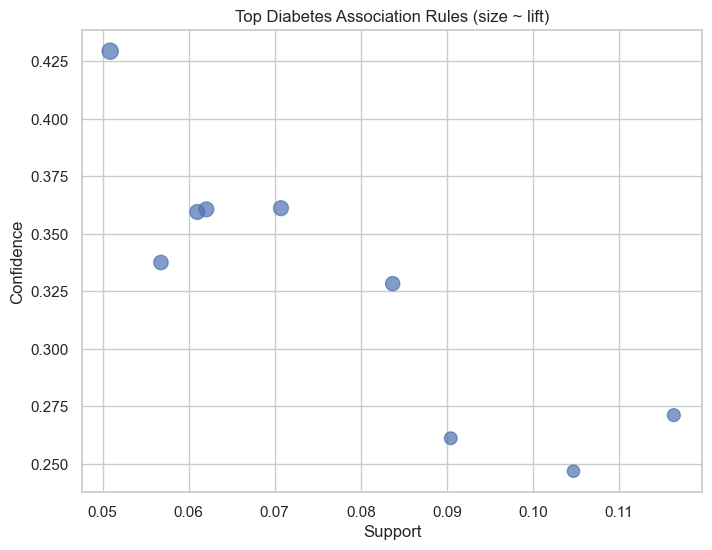

In [15]:
plt.scatter(diabetes_rules['support'], diabetes_rules['confidence'], s=diabetes_rules['lift']*50, alpha=0.7)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Top Diabetes Association Rules (size ~ lift)')
plt.show()

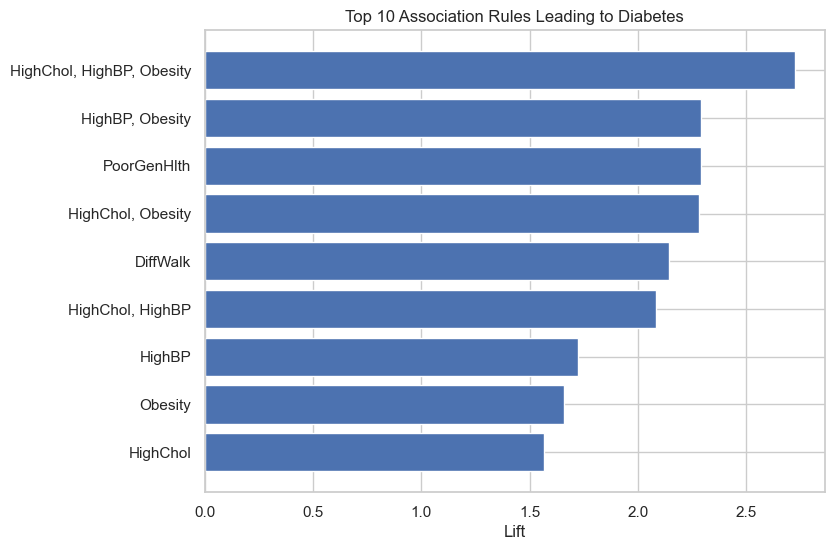

In [16]:
top_rules = diabetes_rules.head(10).copy()

# Convert frozensets to strings for plotting
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))

plt.figure()
plt.barh(top_rules['antecedents'], top_rules['lift'])
plt.xlabel("Lift")
plt.title("Top 10 Association Rules Leading to Diabetes")
plt.gca().invert_yaxis()
plt.show()

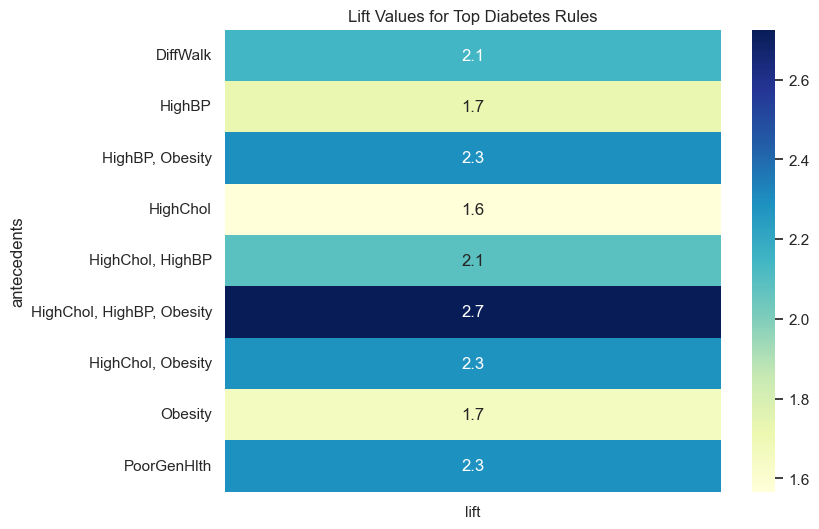

In [17]:
top_rules = diabetes_rules.head(10).copy()

top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))

heatmap_data = top_rules.pivot_table(
    index='antecedents',
    values='lift'
)

sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title("Lift Values for Top Diabetes Rules")
plt.show()

In [18]:
diabetes_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
114,"(HighChol, HighBP, Obesity)",(Diabetes_binary),0.118508,0.157588,0.050891,0.429432,2.725022,1.0,0.032215,1.476443,0.718135,0.225976,0.322696,0.376184
52,"(HighBP, Obesity)",(Diabetes_binary),0.195822,0.157588,0.070727,0.361180,2.291924,1.0,0.039868,1.318701,0.700946,0.250199,0.241678,0.404994
72,(PoorGenHlth),(Diabetes_binary),0.172071,0.157588,0.062062,0.360679,2.288742,1.0,0.034946,1.317666,0.680105,0.231925,0.241083,0.377253
81,"(HighChol, Obesity)",(Diabetes_binary),0.169686,0.157588,0.061010,0.359546,2.281550,1.0,0.034269,1.315334,0.676493,0.229133,0.239737,0.373347
92,(DiffWalk),(Diabetes_binary),0.168224,0.157588,0.056788,0.337575,2.142130,1.0,0.030278,1.271708,0.641008,0.211089,0.213656,0.348966
33,"(HighChol, HighBP)",(Diabetes_binary),0.254888,0.157588,0.083700,0.328379,2.083779,1.0,0.043533,1.254297,0.698020,0.254580,0.202740,0.429755
13,(HighBP),(Diabetes_binary),0.429001,0.157588,0.116355,0.271224,1.721090,1.0,0.048750,1.155926,0.733754,0.247441,0.134893,0.504787
27,(Obesity),(Diabetes_binary),0.346306,0.157588,0.090449,0.261181,1.657362,1.0,0.035875,1.140214,0.606754,0.218768,0.122971,0.417568
18,(HighChol),(Diabetes_binary),0.424121,0.157588,0.104703,0.246870,1.566551,1.0,0.037866,1.118548,0.628005,0.219500,0.105984,0.455639


In [19]:
diabetes_rules.to_csv("../data/processed/association_rules_diabetes.csv", index=False)

In [20]:
diabetes_rules[['antecedents', 'support', 'confidence', 'lift']].head(10)

,antecedents,support,confidence,lift
114,"(HighChol, HighBP, Obesity)",0.050891,0.429432,2.725022
52,"(HighBP, Obesity)",0.070727,0.361180,2.291924
72,(PoorGenHlth),0.062062,0.360679,2.288742
81,"(HighChol, Obesity)",0.061010,0.359546,2.281550
92,(DiffWalk),0.056788,0.337575,2.142130
33,"(HighChol, HighBP)",0.083700,0.328379,2.083779
13,(HighBP),0.116355,0.271224,1.721090
27,(Obesity),0.090449,0.261181,1.657362
18,(HighChol),0.104703,0.246870,1.566551


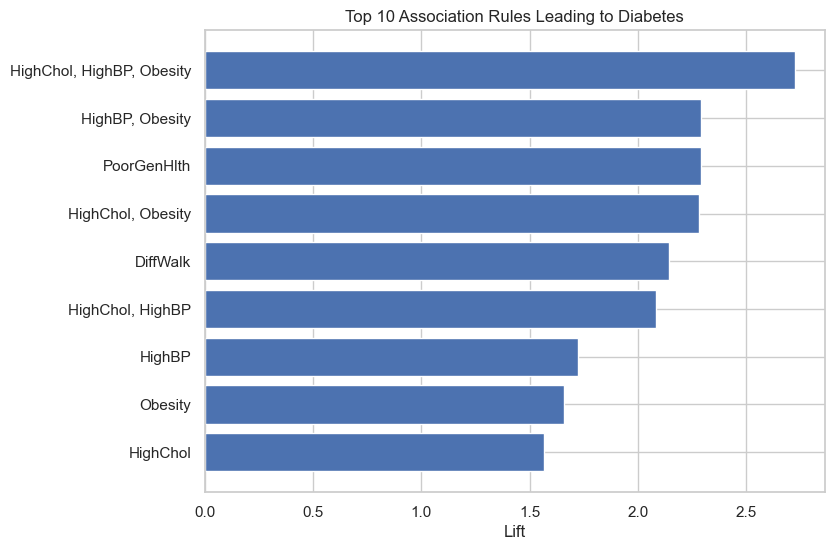

In [21]:
top_rules = diabetes_rules.head(10).copy()
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))

plt.figure()
plt.barh(top_rules['antecedents'], top_rules['lift'])
plt.xlabel("Lift")
plt.title("Top 10 Association Rules Leading to Diabetes")
plt.gca().invert_yaxis()
plt.show()